# 16. Процессы Леви

**Статус:** завершено

Процессы Леви объединяют броуновское движение, пуассоновский процесс, составной Пуассон и более сложные процессы со скачками. Их общая идея: независимые и стационарные приращения.

## Определение и Леви — Хинчин

Процесс $X_t$ называется процессом Леви, если $X_0=0$, приращения независимы, стационарны и процесс стохастически непрерывен.

Характеристическая функция имеет вид

$$\mathbb E[e^{iuX_t}]=e^{t\psi(u)},$$

где показатель Леви — Хинчина

$$\psi(u)=i\gamma u-\frac12\sigma^2u^2+\int_{\mathbb R}\left(e^{iux}-1-iux\mathbf 1_{|x|<1}\right)\nu(dx).$$

Триплет Леви $(\gamma,\sigma^2,\nu)$ разделяет drift, диффузию и скачки. Броуновское движение имеет только диффузионную часть, пуассоновский процесс — скачковую, составной Пуассон — скачки случайного размера.

In [1]:
import os
import sys
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

from Scripts.levy_processes import (
    calculate_brownian_characteristic_function,
    calculate_compound_poisson_normal_jump_characteristic_function,
    calculate_empirical_characteristic_function,
    plot_characteristic_function_comparison,
    plot_levy_process_paths,
    simulate_brownian_motion_paths,
    simulate_compound_poisson_normal_paths,
    simulate_compound_poisson_normal_terminal_values,
    simulate_poisson_process_paths,
    simulate_variance_gamma_terminal_values,
)

## 1. Три траектории процессов Леви

,Процесс,E[X(1)] симуляция,Var[X(1)] симуляция
0,Brownian,0.0228,1.0129
1,Poisson,3.9762,4.0027
2,Compound Poisson,0.6140,1.5622


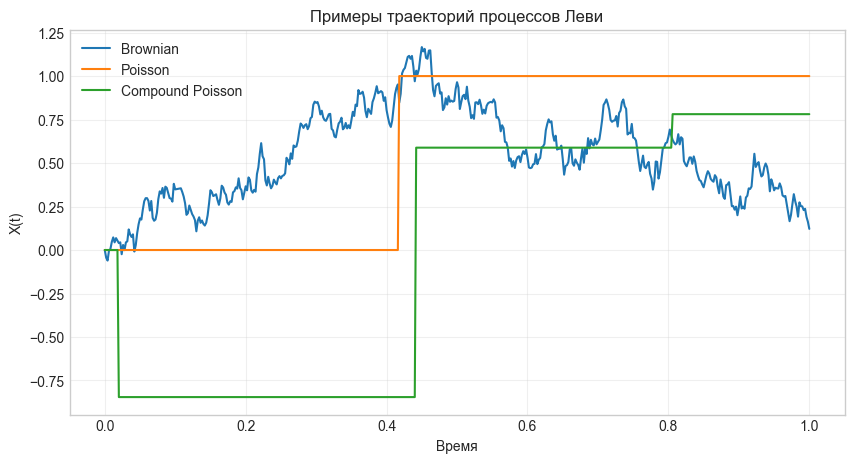

In [2]:
time_grid, brownian_paths = simulate_brownian_motion_paths(4000, 500, 1.0, 1.0, random_seed=123)
_, poisson_paths = simulate_poisson_process_paths(4000, 500, 1.0, 4.0, random_seed=123)
_, compound_paths = simulate_compound_poisson_normal_paths(4000, 500, 1.0, 3.0, 0.2, 0.7, random_seed=123)
plot_levy_process_paths(time_grid, {"Brownian": brownian_paths, "Poisson": poisson_paths, "Compound Poisson": compound_paths}, "Примеры траекторий процессов Леви");

pd.DataFrame({
    "Процесс": ["Brownian", "Poisson", "Compound Poisson"],
    "E[X(1)] симуляция": [brownian_paths[:,-1].mean(), poisson_paths[:,-1].mean(), compound_paths[:,-1].mean()],
    "Var[X(1)] симуляция": [brownian_paths[:,-1].var(), poisson_paths[:,-1].var(), compound_paths[:,-1].var()],
})

Brownian-траектория непрерывна, Poisson — ступенчатая с единичными скачками, compound Poisson — ступенчатая со случайными размерами скачков. Все три процесса имеют независимые стационарные приращения, но геометрия траекторий совершенно разная.

## 2. Характеристическая функция

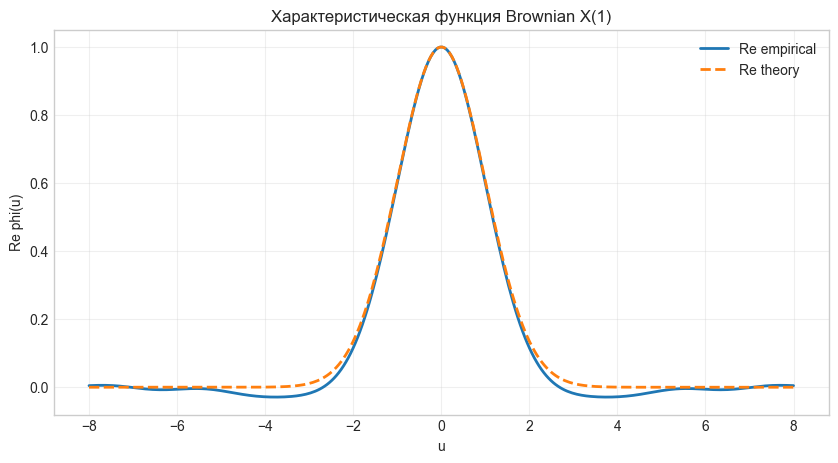

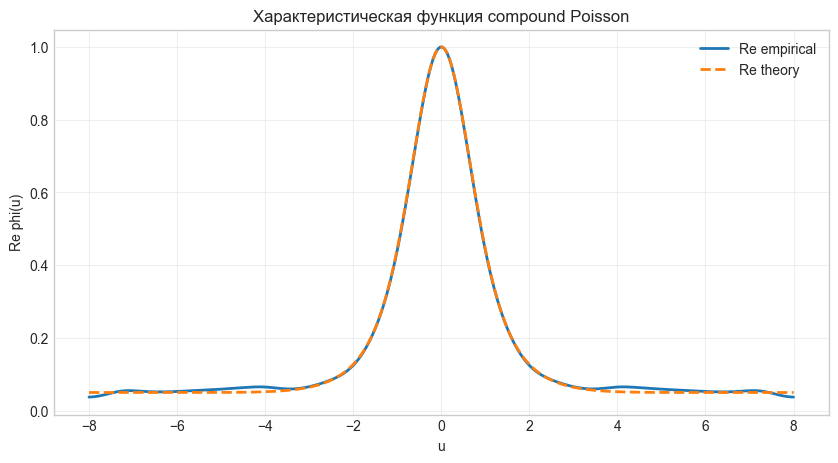

In [3]:
terminal_brownian = brownian_paths[:, -1]
u_values = np.linspace(-8, 8, 300)
empirical_brownian_cf = calculate_empirical_characteristic_function(terminal_brownian, u_values)
theoretical_brownian_cf = calculate_brownian_characteristic_function(u_values, 1.0, 1.0)
plot_characteristic_function_comparison(u_values, empirical_brownian_cf, theoretical_brownian_cf, "Характеристическая функция Brownian X(1)");

compound_terminal = simulate_compound_poisson_normal_terminal_values(8000, 1.0, 3.0, 0.2, 0.7, random_seed=321)
empirical_compound_cf = calculate_empirical_characteristic_function(compound_terminal, u_values)
theoretical_compound_cf = calculate_compound_poisson_normal_jump_characteristic_function(u_values, 1.0, 3.0, 0.2, 0.7)
plot_characteristic_function_comparison(u_values, empirical_compound_cf, theoretical_compound_cf, "Характеристическая функция compound Poisson");

Характеристическая функция особенно удобна для процессов Леви, потому что независимость приращений превращается в экспоненту по времени: $\phi_t(u)=\exp(t\psi(u))$. На графиках эмпирические real parts хорошо повторяют теоретические. В финансах это свойство используют для Fourier pricing.

## 3. Бесконечная активность и тяжёлые хвосты: variance-gamma

In [4]:
variance_gamma_terminal = simulate_variance_gamma_terminal_values(8000, 1.0, theta=-0.1, sigma=0.35, nu=0.25, random_seed=123)
pd.DataFrame({
    "Показатель": ["mean", "variance", "1%-квантиль", "99%-квантиль"],
    "Значение": [variance_gamma_terminal.mean(), variance_gamma_terminal.var(), np.quantile(variance_gamma_terminal,.01), np.quantile(variance_gamma_terminal,.99)]
})

,Показатель,Значение
0,mean,-0.1037
1,variance,0.1279
2,1%-квантиль,-1.0416
3,99%-квантиль,0.7213


Variance-gamma можно понимать как броуновское движение, запущенное по случайным gamma-часам. Оно даёт более тяжёлые хвосты и асимметрию без простой конечной активности скачков. В симуляции 1%- и 99%-квантили около `-1.0416` и `0.7213`, что показывает заметную левую асимметрию при $\theta<0$.

## Выводы

1. Процессы Леви имеют независимые и стационарные приращения.
2. Brownian, Poisson и compound Poisson — базовые строительные блоки.
3. Триплет Леви разделяет drift, diffusion и jump measure.
4. Характеристические функции естественны, потому что имеют форму $e^{t\psi(u)}$.
5. Более сложные процессы, вроде variance-gamma, позволяют моделировать тяжёлые хвосты и асимметрию финансовых доходностей.